# Панельная регрессия: Анализ взаимосвязи золота и золотодобывающих индексов

## Методология (на основе научных работ):
- **Petersen (2009)**: В финансовых исследованиях рекомендуется использовать clustered standard errors
- **Cameron & Miller (2015)**: Для панелей с N > T (как в нашем случае) - clustered errors предпочтительны
- **Greene (2012)**: Выбор между FE и RE на основе теста Хаусмана

## Содержание:
1. Подготовка данных в панельном формате
2. Тесты на стационарность (ADF, KPSS)
3. Построение панельных моделей (Pooled OLS, FE, RE)
4. Тест Хаусмана для выбора между FE и RE
5. Диагностика моделей
6. Интерпретация результатов

In [1]:
# Установка необходимых библиотек
# !pip install linearmodels statsmodels pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects, compare
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [3]:
# # =============================================================================
# # ВЫБОР ИСТОЧНИКА ДАННЫХ
# # =============================================================================

# # ВАРИАНТ 1: Загрузка из Yahoo Finance (новые данные) - ЗАКОММЕНТИРОВАН
# from data_loader import load_fresh_data
# merged_df = load_fresh_data(data_type='all', use_yahoo=True)

In [4]:
# # Вывод начала и конца дат для каждого индекса
# print("\n📊 merged_df (Yahoo Finance) - даты для каждого индекса:")
# for col in merged_df.columns:
#     if col != 'Date':
#         valid_dates = merged_df[merged_df[col].notna()]['Date']
#         if len(valid_dates) > 0:
#             print(f"  {col}: {valid_dates.min().date()} - {valid_dates.max().date()}")


In [5]:
# ВАРИАНТ 2: Загрузка из файлов (старые данные из data2) - РАСКОММЕНТИРОВАН
import pandas as pd
import glob
import numpy as np

# Конфигурация файлов с правильными форматами дат
# Индексы золотодобычи
files_config = [
    {"path": "data2/Прошлые данные - Arca Gold Miners.csv", "col_name": "GDM"},
    # {"path": "data2/Прошлые данные - MSCI ACWI IMI.csv", "col_name": "MSCI"},
    # {"path": "data2/Прошлые данные - MVIS Global Junior Gold Miners TR Net.csv", "col_name": "MVG"},
    {"path": "data2/Прошлые данные по XGD.csv", "col_name": "XGD"},
    {"path": "data2/Прошлые данные по GDX.csv", "col_name": "GDX"},
    {"path": "data2/Прошлые данные - FTSE Gold Mines.csv", "col_name": "FTGM"},
    {"path": "data2/Прошлые данные - Arca Gold BUGS.csv", "col_name": "HUI"},
    {"path": "data2/Прошлые данные - Philadelphia Gold_Silver.csv", "col_name": "XAU"},
]

# Макро данные
macro_files = [
    {"path": "data2/Прошлые данные - XAU_USD.csv", "col_name": "Gold"},
    {"path": "data2/Прошлые данные - S&P 500.csv", "col_name": "SP500"},
    {"path": "data2/Прошлые данные - Индекс USD.csv", "col_name": "USD"},
    {"path": "data2/Прошлые данные - Фьючерс на нефть Brent.csv", "col_name": "Oil"},
    {"path": "data2/Прошлые данные - CBOE Volatility Index.csv", "col_name": "Vix"},
    # {"path": "data2/United States 10-Year Bond Yield Historical Data (2).csv", "col_name": "INT", "date_col": "Date", "price_col": "Price"},
]

# EPU данные (специальный формат - год, месяц, день)
# epu_config = {"path": "data2/All_Daily_Policy_Data.csv", "col_name": "EPU"}

def load_data_file(config):
    """Загрузка одного файла данных с автоматическим определением формата"""
    try:
        df = pd.read_csv(config["path"])
        
        # Проверяем, это EPU файл
        if config.get("col_name") == "EPU":
            # Создаем дату из year, month, day
            df['Date'] = pd.to_datetime(df[['year', 'month', 'day']])
            df = df[['Date', 'daily_policy_index']].rename(columns={'daily_policy_index': config["col_name"]})
            df = df[df['Date'] >= '2003-01-01']
        else:
            # Автоматически определяем колонки
            date_col = None
            price_col = None
            
            # Ищем колонку с датой
            for col in df.columns:
                col_lower = col.lower()
                if 'date' in col_lower or 'дата' in col_lower:
                    date_col = col
                    break
            
            # Ищем колонку с ценой ( Price, Цена или первая числовая)
            if 'Price' in df.columns:
                price_col = 'Price'
            elif 'Цена' in df.columns:
                price_col = 'Цена'
            else:
                numeric_cols = df.select_dtypes(include=[np.number]).columns
                if len(numeric_cols) > 0:
                    price_col = numeric_cols[0]
            
            if date_col is None or price_col is None:
                print(f"  ⚠️ Не удалось определить колонки для {config['col_name']}: columns={list(df.columns)}")
                return None
            
            # Парсим дату
            if date_col == "Date":
                # Английский формат (MM/DD/YYYY)
                df['Date'] = pd.to_datetime(df[date_col], format='%m/%d/%Y')
            else:
                # Русский формат (DD.MM.YYYY)
                df['Date'] = pd.to_datetime(df[date_col], format='%d.%m.%Y')
            
            # Конвертируем цену в числовой формат
            if df[price_col].dtype == 'object':
                # Убираем пробелы, меняем точки на пустоту, запятые на точки
                df[price_col] = df[price_col].astype(str).str.replace(' ', '', regex=False)
                df[price_col] = df[price_col].str.replace('.', '', regex=False)
                df[price_col] = df[price_col].str.replace(',', '.', regex=False)
                df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
            
            df = df[['Date', price_col]].rename(columns={price_col: config["col_name"]})
            df = df[df['Date'] >= '2003-01-01']
        
        df = df.drop_duplicates(subset=['Date'], keep='first')
        df = df.dropna()
        df = df.sort_values('Date').reset_index(drop=True)
        
        return df
    except Exception as e:
        print(f"Error loading {config['col_name']}: {e}")
        return None


# Загрузка данных
dataframes = {}

# Загружаем индексы золотодобычи
for config in files_config:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records ({df['Date'].min().date()} - {df['Date'].max().date()})")

# Загружаем макро данные
for config in macro_files:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records ({df['Date'].min().date()} - {df['Date'].max().date()})")

# Загружаем EPU
# df = load_data_file(epu_config)
# if df is not None:
#     dataframes[epu_config["col_name"]] = df
#     print(f"Loaded {epu_config['col_name']}: {len(df)} records ({df['Date'].min().date()} - {df['Date'].max().date()})")

print(f"\nTotal indices loaded: {len(dataframes)}")
print(f"Loaded indices: {list(dataframes.keys())}")

# Объединение всех данных по дате
merged_df = None
for name, df in dataframes.items():
    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, on='Date', how='outer')

merged_df = merged_df.sort_values('Date').reset_index(drop=True)
print(f"\nTotal merged: {len(merged_df)} records")
print(f"Date range: {merged_df['Date'].min()} - {merged_df['Date'].max()}")
print(f"Columns: {list(merged_df.columns)}")

Loaded GDM: 4759 records (2007-02-20 - 2025-12-15)
Loaded XGD: 4727 records (2007-02-16 - 2025-12-16)
Loaded GDX: 4768 records (2007-02-20 - 2025-12-16)
Loaded FTGM: 4919 records (2007-02-19 - 2025-12-15)
Loaded HUI: 3914 records (2010-05-18 - 2025-12-15)
Loaded XAU: 4741 records (2007-02-20 - 2025-12-16)
Loaded Gold: 4902 records (2007-02-19 - 2025-12-16)
Loaded SP500: 4738 records (2007-02-20 - 2025-12-16)
Loaded USD: 4895 records (2007-02-20 - 2025-12-16)
Loaded Oil: 4863 records (2007-02-19 - 2025-12-16)
Loaded Vix: 4777 records (2007-02-20 - 2025-12-16)

Total indices loaded: 11
Loaded indices: ['GDM', 'XGD', 'GDX', 'FTGM', 'HUI', 'XAU', 'Gold', 'SP500', 'USD', 'Oil', 'Vix']

Total merged: 4985 records
Date range: 2007-02-16 00:00:00 - 2025-12-16 00:00:00
Columns: ['Date', 'GDM', 'XGD', 'GDX', 'FTGM', 'HUI', 'XAU', 'Gold', 'SP500', 'USD', 'Oil', 'Vix']


In [6]:
# # =============================================================================
# # СРАВНЕНИЕ ДАННЫХ ПОД ОДИНАКОВОЙ ДАТОЙ
# # =============================================================================

# print("\n" + "="*60)
# print("СРАВНЕНИЕ ДАННЫХ: Yahoo (merged_df) vs Файлы (merged_df)")
# print("="*60)

# # Выбираем конкретную дату для сравнения (например, последнюю общую дату)
# # Находим общие даты
# common_dates = set(merged_df['Date']).intersection(set(merged_df['Date']))
# common_dates = sorted(common_dates)

# if len(common_dates) > 0:
#     # Берем дату примерно в середине периода (или последнюю)
#     compare_date = common_dates[len(common_dates)//2]  # средняя дата
#     # compare_date = common_dates[-1]  # последняя дата
    
#     print(f"\n📅 Сравнение для даты: {compare_date.date()}\n")
    
#     # Получаем строки для этой даты
#     row_yahoo = merged_df[merged_df['Date'] == compare_date].iloc[0]
#     row_files = merged_df[merged_df['Date'] == compare_date].iloc[0]
    
#     # Находим общие колонки (кроме 'Date')
#     common_cols = set(merged_df.columns).intersection(set(merged_df.columns))
#     common_cols = [col for col in common_cols if col != 'Date']
#     common_cols = sorted(common_cols)
    
#     print(f"Найдено общих колонок: {len(common_cols)}")
#     print(f"Общие колонки: {common_cols}\n")
    
#     # Таблица сравнения
#     print(f"{'Колонка':<15} {'Yahoo (merged_df)':>20} {'Файлы (merged_df)':>20} {'Разница %':>15}")
#     print("-"*75)
    
#     for col in common_cols:
#         val_yahoo = row_yahoo[col]
#         val_files = row_files[col]
        
#         # Проверяем, что оба значения не NaN
#         if pd.notna(val_yahoo) and pd.notna(val_files):
#             diff_pct = ((val_yahoo - val_files) / val_files) * 100 if val_files != 0 else float('inf')
#             print(f"{col:<15} {val_yahoo:>20.4f} {val_files:>20.4f} {diff_pct:>14.2f}%")
#         else:
#             yahoo_str = f"{val_yahoo:.4f}" if pd.notna(val_yahoo) else "NaN"
#             files_str = f"{val_files:.4f}" if pd.notna(val_files) else "NaN"
#             print(f"{col:<15} {yahoo_str:>20} {files_str:>20} {'N/A':>15}")
    
#     # Статистика по всем датам (средняя разница)
#     print("\n" + "="*60)
#     print("СТАТИСТИКА ПО ВСЕМ ОБЩИМ ДАТАМ")
#     print("="*60)
    
#     # Объединяем по дате для сравнения всех значений
#     compare_df = pd.merge(merged_df, merged_df, on='Date', suffixes=('_yahoo', '_files'), how='inner')
    
#     for col in common_cols:
#         col_yahoo = f"{col}_yahoo"
#         col_files = f"{col}_files"
        
#         if col_yahoo in compare_df.columns and col_files in compare_df.columns:
#             # Убираем NaN
#             valid = compare_df[compare_df[col_yahoo].notna() & compare_df[col_files].notna()]
            
#             if len(valid) > 0:
#                 # Средняя абсолютная разница в процентах
#                 pct_diff = abs((valid[col_yahoo] - valid[col_files]) / valid[col_files] * 100)
#                 pct_diff = pct_diff.replace([float('inf'), -float('inf')], float('nan')).dropna()
                
#                 if len(pct_diff) > 0:
#                     mean_diff = pct_diff.mean()
#                     max_diff = pct_diff.max()
#                     print(f"{col:<15}: общих дат: {len(valid):4}, средняя разница: {mean_diff:6.2f}%, макс: {max_diff:6.2f}%")
#                 else:
#                     print(f"{col:<15}: общих дат: {len(valid):4}, но нет валидных сравнений")
    
# else:
#     print("❌ Нет общих дат между merged_df и merged_df")

## 1. Расчет доходностей

In [7]:
# Расчет доходностей (логарифмические разности)
returns_df = merged_df.copy()
price_cols = [col for col in merged_df.columns if col != 'Date']

for col in price_cols:
    returns_df[f'{col}_ret'] = np.log(merged_df[col]).diff()

returns_cols = ['Date'] + [f'{col}_ret' for col in price_cols]
returns_df = returns_df[returns_cols]

print(f"📊 Размерность после расчета доходностей: {returns_df.shape}")
print(f"Колонки: {list(returns_df.columns)}")

📊 Размерность после расчета доходностей: (4985, 12)
Колонки: ['Date', 'GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'HUI_ret', 'XAU_ret', 'Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret', 'Vix_ret']


## 2. Преобразование в панельный формат

In [8]:
# Определяем переменные для модели
macro_vars = ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret', 'Vix_ret', 'INT_ret', 'EPU_ret']
mining_indices = ['GDM_ret', 'MVG_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'HUI_ret', 'XAU_ret']

available_mining = [col for col in mining_indices if col in returns_df.columns]
available_macro = [col for col in macro_vars if col in returns_df.columns]

print(f"✅ Доступные индексы золотодобытчиков: {len(available_mining)}")
print(f"   {available_mining}")
print(f"✅ Доступные макро переменные: {len(available_macro)}")
print(f"   {available_macro}")

✅ Доступные индексы золотодобытчиков: 6
   ['GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'HUI_ret', 'XAU_ret']
✅ Доступные макро переменные: 5
   ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret', 'Vix_ret']


In [9]:
# Преобразование в long format
panel_data_list = []

for idx_col in available_mining:
    idx_name = idx_col.replace('_ret', '')
    temp_df = returns_df[['Date'] + available_macro + [idx_col]].copy()
    temp_df = temp_df.rename(columns={idx_col: 'Index_Return'})
    temp_df['Index_ID'] = idx_name
    temp_df = temp_df.dropna()
    panel_data_list.append(temp_df)

panel_df = pd.concat(panel_data_list, ignore_index=True)
panel_df = panel_df.set_index(['Index_ID', 'Date'])

print(f"📊 Панельные данные: {panel_df.index.get_level_values(0).nunique()} индексов, {len(panel_df)} наблюдений")

📊 Панельные данные: 6 индексов, 26068 наблюдений


## 3. Тесты на стационарность (ADF и KPSS)

In [10]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF_Statistic': result[0],
        'p_value': result[1],
        'Stationary': result[1] < 0.05
    }

def kpss_test(series, name=''):
    try:
        result = kpss(series.dropna(), regression='c', nlags='auto')
        return {
            'Variable': name,
            'KPSS_Statistic': result[0],
            'p_value': result[1],
            'Stationary': result[1] > 0.05
        }
    except:
        return None

print('='*80)
print("📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ")
print("="*80)

adf_results = []
for col in panel_df.columns:
    result = adf_test(panel_df[col], col)
    adf_results.append(result)
    status = "✅" if result['Stationary'] else "❌"
    print(f"{col:20} | p-value: {result['p_value']:.4f} | {status}")

adf_df = pd.DataFrame(adf_results)

kpss_results = []
for col in panel_df.columns:
    result = kpss_test(panel_df[col], col)
    if result:
        kpss_results.append(result)

if kpss_results:
    kpss_df = pd.DataFrame(kpss_results)
    
stationarity_summary = pd.DataFrame({
    'Variable': adf_df['Variable'],
    'ADF_pvalue': adf_df['p_value'],
    'ADF_Stationary': adf_df['Stationary']
})

all_stationary = stationarity_summary['ADF_Stationary'].all()
print(f"\n📊 Вывод: Все ряды стационарны = {all_stationary}")

📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ
Gold_ret             | p-value: 0.0000 | ✅
SP500_ret            | p-value: 0.0000 | ✅
USD_ret              | p-value: 0.0000 | ✅
Oil_ret              | p-value: 0.0000 | ✅
Vix_ret              | p-value: 0.0000 | ✅
Index_Return         | p-value: 0.0000 | ✅

📊 Вывод: Все ряды стационарны = True


## 4. Проверка мультиколлинеарности (VIF)

In [11]:
print("="*80)
print("📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("="*80)

X = panel_df[available_macro].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n📋 Результаты VIF:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] >= 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Переменные с VIF ≥ 10: {high_vif['Variable'].tolist()}")
else:
    print("\n✅ Нет сильной мультиколлинеарности")

📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)

📋 Результаты VIF:
 Variable      VIF
 Gold_ret 1.238134
SP500_ret 2.373317
  USD_ret 1.262347
  Oil_ret 1.136067
  Vix_ret 2.235701

✅ Нет сильной мультиколлинеарности


## 5. Построение панельных моделей

**Методология:**
- Pooled OLS: базовая модель
- Fixed Effects (FE): учитывает индивидуальные эффекты
- Random Effects (RE): альтернативная спецификация
- Используем clustered standard errors (рекомендация для финансовых данных)

In [12]:
# Подготовка данных
dependent = panel_df['Index_Return']
exog = panel_df[available_macro]

print("="*80)
print("📊 ОЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ")
print("="*80)

# 1. Pooled OLS
print("\n1️⃣ POOLED OLS")
print("-"*80)
model_pooled = PooledOLS(dependent=dependent, exog=exog)
results_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(results_pooled.summary)

📊 ОЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ

1️⃣ POOLED OLS
--------------------------------------------------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:           Index_Return   R-squared:                        0.6186
Estimator:                  PooledOLS   R-squared (Between):             -60.833
No. Observations:               26068   R-squared (Within):               0.6193
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.6186
Time:                        18:44:13   Log-likelihood                 7.269e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8455.4
Entities:                           6   P-value                           0.0000
Avg Obs:                       4344.7   Distribution:                 F(5,26063)
Min Obs:                       3711.0                             

In [29]:
# 2. Fixed Effects
print("\n2️⃣ FIXED EFFECTS (FE)")
print("-"*80)
model_fe = PanelOLS(dependent=dependent, exog=exog, entity_effects=True)
# results_fe = model_fe.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
results_fe = model_fe.fit(
    cov_type='kernel',           # HAC / Newey-West тип
    kernel='bartlett',           # или 'parzen'
    bandwidth=20                 # можно попробовать 10, 20, 30
)
print(results_fe.summary)


2️⃣ FIXED EFFECTS (FE)
--------------------------------------------------------------------------------
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6193
Estimator:                   PanelOLS   R-squared (Between):             -61.088
No. Observations:               26068   R-squared (Within):               0.6193
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.6186
Time:                        18:48:43   Log-likelihood                 7.271e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      8476.2
Entities:                           6   P-value                           0.0000
Avg Obs:                       4344.7   Distribution:                 F(5,26057)
Min Obs:                       3711.0                                           
Max 

In [14]:
# 3. Random Effects
print("\n3️⃣ RANDOM EFFECTS (RE)")
print("-"*80)
model_re = RandomEffects(dependent=dependent, exog=exog)
results_re = model_re.fit()
print(results_re.summary)


3️⃣ RANDOM EFFECTS (RE)
--------------------------------------------------------------------------------
                        RandomEffects Estimation Summary                        
Dep. Variable:           Index_Return   R-squared:                        0.6186
Estimator:              RandomEffects   R-squared (Between):             -60.833
No. Observations:               26068   R-squared (Within):               0.6193
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.6186
Time:                        18:44:14   Log-likelihood                 7.269e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      8455.4
Entities:                           6   P-value                           0.0000
Avg Obs:                       4344.7   Distribution:                 F(5,26063)
Min Obs:                       3711.0                                           
Max

## 6. Сравнение моделей и тест Хаусмана

In [15]:
# Сравнение моделей
print("="*80)
print("📊 СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)

comparison = compare({
    'Pooled OLS': results_pooled,
    'Fixed Effects': results_fe,
    'Random Effects': results_re
})
print(comparison)

📊 СРАВНЕНИЕ МОДЕЛЕЙ
                              Model Comparison                             
                              Pooled OLS    Fixed Effects    Random Effects
---------------------------------------------------------------------------
Dep. Variable               Index_Return     Index_Return      Index_Return
Estimator                      PooledOLS         PanelOLS     RandomEffects
No. Observations                   26068            26068             26068
Cov. Est.                      Clustered        Clustered        Unadjusted
R-squared                         0.6186           0.6193            0.6186
R-Squared (Within)                0.6193           0.6193            0.6193
R-Squared (Between)              -60.833          -61.088           -60.833
R-Squared (Overall)               0.6186           0.6186            0.6186
F-statistic                       8455.4           8476.2            8455.4
P-value (F-stat)                  0.0000           0.0000           

In [30]:
print("\n" + "="*80)
print("📊 ТЕСТ ХАУСМАНА (FE vs RE)")
print("="*80)

from scipy.stats import chi2
import numpy as np


def hausman_test(fe_results, re_results):
    """
    Упрощенный тест Хаусмана
    """
    # Получаем коэффициенты
    b_fe = fe_results.params
    b_re = re_results.params
    
    # Общие переменные
    common = b_fe.index.intersection(b_re.index)
    b_fe = b_fe[common]
    b_re = b_re[common]
    
    # Ковариационные матрицы
    cov_fe = fe_results.cov.loc[common, common]
    cov_re = re_results.cov.loc[common, common]
    
    # Разность
    diff = b_re - b_fe
    cov_diff = cov_re - cov_fe
    
    # Тест
    try:
        # Используем псевдо-обратную для устойчивости
        cov_diff_inv = np.linalg.pinv(cov_diff.values)
        H = diff.values.T @ cov_diff_inv @ diff.values
        df = np.linalg.matrix_rank(cov_diff.values)
        p_value = 1 - chi2.cdf(H, df)
        
        print(f"\n📊 Результаты теста Хаусмана:")
        print(f"  Статистика: {H:.4f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Степени свободы: {df}")
        
        if p_value < 0.05 and not np.isnan(p_value):
            print(f"\n✅ p < 0.05 → Fixed Effects предпочтительнее")
            print(f"  (RE может давать смещенные оценки)")
            return "FE"
        elif p_value >= 0.05 and not np.isnan(p_value):
            print(f"\n✅ p > 0.05 → Random Effects допустима")
            print(f"  (RE более эффективна)")
            return "RE"
        else:
            print(f"\n⚠️ p-value = {p_value} (некорректное значение)")
            print(f"  Рекомендация: Использовать Fixed Effects для надежности")
            return "FE"
            
    except Exception as e:
        print(f"\n⚠️ Тест Хаусмана не проведен: {e}")
        print(f"💡 Рекомендация: Использовать Fixed Effects (консервативный подход)")
        return "FE"

# Запускаем тест
hausman_choice = hausman_test(results_fe, results_re)

# Дополнительная проверка: если коэффициенты очень близки
print("\n📊 Дополнительная проверка:")
coef_diff = np.abs(results_fe.params - results_re.params).max()
print(f"  Максимальная разница коэффициентов: {coef_diff:.6f}")

if coef_diff < 0.01:
    print(f"  ✅ Коэффициенты практически идентичны")
    print(f"  → Можно использовать более простую RE модель")
else:
    print(f"  ⚠️ Есть заметные различия в коэффициентах")
    print(f"  → FE предпочтительнее для надежности")


📊 ТЕСТ ХАУСМАНА (FE vs RE)

📊 Результаты теста Хаусмана:
  Статистика: -0.0043
  p-value: 1.0000
  Степени свободы: 5

✅ p > 0.05 → Random Effects допустима
  (RE более эффективна)

📊 Дополнительная проверка:
  Максимальная разница коэффициентов: 0.002496
  ✅ Коэффициенты практически идентичны
  → Можно использовать более простую RE модель


In [31]:
# =============================================================================
# ТЕСТ ХАУСМАНА: FE vs RE
# =============================================================================

print("\n" + "="*80)
print("ТЕСТ ХАУСМАНА: Fixed Effects vs Random Effects")
print("="*80)

try:
    # Стандартный тест Хаусмана из linearmodels
    hausman_res = results_fe.compare(results_re, precision='cov')
    print(hausman_res)
    
    # Или более детальный вывод
    print("\nHausman statistic:", hausman_res.stat)
    print("Degrees of freedom:", hausman_res.df)
    print("p-value:", hausman_res.pval)
    
    if hausman_res.pval < 0.05:
        print("→ Отвергаем H0 → предпочтительна Fixed Effects")
    else:
        print("→ Не отвергаем H0 → предпочтительна Random Effects (или обе допустимы)")
        
except Exception as e:
    print("Ошибка при сравнении FE и RE:", str(e))
    print("Попробуйте ручной расчёт ниже.")
    
    # Ручной расчёт (если compare не работает)
    from scipy.stats import chi2
    diff_param = results_fe.params - results_re.params
    diff_cov   = results_fe.cov - results_re.cov
    
    # Только общие параметры (исключаем константу и эффекты, если нужно)
    common_params = diff_param.index.intersection(diff_cov.index)
    diff_param = diff_param[common_params]
    diff_cov   = diff_cov.loc[common_params, common_params]
    
    stat = diff_param.T @ np.linalg.inv(diff_cov) @ diff_param
    df   = len(common_params)
    pval = 1 - chi2.cdf(stat, df)
    
    print(f"Ручной Hausman statistic: {stat:.4f}")
    print(f"Degrees of freedom: {df}")
    print(f"p-value: {pval:.6f}")


ТЕСТ ХАУСМАНА: Fixed Effects vs Random Effects
Ошибка при сравнении FE и RE: 'PanelEffectsResults' object has no attribute 'compare'
Попробуйте ручной расчёт ниже.
Ручной Hausman statistic: 0.0043
Degrees of freedom: 5
p-value: 1.000000


In [32]:
# =============================================================================
# 2. WALD-ТЕСТ на β_gold = 1 (самый надёжный вариант — тот, что ты уже запустила)
# =============================================================================

gold_var = 'Gold_ret'  # ← если имя другое — измени здесь

print("\n" + "="*80)
print("WALD / t-ТЕСТ НА ГИПОТЕЗУ β_gold = 1 (H1: β > 1)")
print("="*80)

if gold_var in results_fe.params.index:
    beta = results_fe.params[gold_var]
    se   = results_fe.std_errors[gold_var]
    t_stat = (beta - 1) / se
    df     = results_fe.df_resid
    from scipy.stats import t
    p_one = 1 - t.cdf(t_stat, df) if t_stat > 0 else 1.0
    
    print(f"β_gold          = {beta:.4f}")
    print(f"Robust SE       = {se:.4f}")
    print(f"t-stat (β=1)    = {t_stat:.4f}")
    print(f"df              ≈ {df:.0f}")
    print(f"p-value (β > 1) = {p_one:.10f}")
    
    if p_one < 0.01:
        print("→ Гипотеза β_gold > 1 принимается на 1% уровне")
    elif p_one < 0.05:
        print("→ Принимается на 5% уровне")
    else:
        print("→ Не принимается")
else:
    print(f"Переменная {gold_var} не найдена!")


WALD / t-ТЕСТ НА ГИПОТЕЗУ β_gold = 1 (H1: β > 1)
β_gold          = 1.5888
Robust SE       = 0.0493
t-stat (β=1)    = 11.9352
df              ≈ 26057
p-value (β > 1) = 0.0000000000
→ Гипотеза β_gold > 1 принимается на 1% уровне


In [33]:
# =============================================================================
# 3. F-тест на совместную значимость всех макрофакторов (кроме Gold_ret)
# =============================================================================

print("\n" + "="*80)
print("F-ТЕСТ: совместная значимость макрофакторов (USD, Oil, SP500, Vix)")
print("="*80)

vars_macro = ['USD_ret', 'Oil_ret', 'SP500_ret', 'Vix_ret']  # ← подставь свои имена
formula = " = 0, ".join(vars_macro) + " = 0"

f_test = results_fe.f_test(formula)
print(f_test)
print(f"F-statistic: {f_test.statistic:.4f}")
print(f"p-value: {f_test.pvalue:.6f}")

if f_test.pvalue < 0.05:
    print("→ Макрофакторы совместно значимы")
else:
    print("→ Макрофакторы совместно незначимы")


F-ТЕСТ: совместная значимость макрофакторов (USD, Oil, SP500, Vix)


AttributeError: 'PanelEffectsResults' object has no attribute 'f_test'

In [34]:
# =============================================================================
# 4. VIF — мультиколлинеарность (если ещё не делала)
# =============================================================================

print("\n" + "="*80)
print("VARIANCE INFLATION FACTORS (VIF)")
print("="*80)

exog_names = ['const'] + [col for col in panel_data.columns if col in ['Gold_ret', 'USD_ret', 'Oil_ret', 'SP500_ret', 'Vix_ret']]
exog = sm.add_constant(panel_data[exog_names[1:]])  # без константы не нужно

vif_data = pd.DataFrame()
vif_data["Переменная"] = exog_names
vif_data["VIF"] = [variance_inflation_factor(exog.values, i) for i in range(exog.shape[1])]

print(vif_data.round(2))


VARIANCE INFLATION FACTORS (VIF)


NameError: name 'panel_data' is not defined

In [35]:
# F-тест Pooled vs FE
print("\n" + "="*80)
print("📊 F-ТЕСТ: POOLED OLS vs FIXED EFFECTS")
print("="*80)

rss_pooled = results_pooled.resid_ss
rss_fe = results_fe.resid_ss

n = len(panel_df)
k = len(available_macro) + 1
N = panel_df.index.get_level_values(0).nunique()

F_stat = ((rss_pooled - rss_fe) / (N - 1)) / (rss_fe / (n - N - k))
p_value_f = 1 - stats.f.cdf(F_stat, N - 1, n - N - k)

print(f"  F-статистика: {F_stat:.4f}")
print(f"  p-value: {p_value_f:.4f}")

if p_value_f < 0.05:
    print(f"\n✅ FE значимо лучше Pooled OLS")
else:
    print(f"\n⚠️ FE незначимо лучше Pooled OLS")


📊 F-ТЕСТ: POOLED OLS vs FIXED EFFECTS
  F-статистика: 8.7240
  p-value: 0.0000

✅ FE значимо лучше Pooled OLS


## 7. Диагностика модели

In [36]:
best_model = results_fe
best_name = "Fixed Effects"

print("="*80)
print(f"📊 ДИАГНОСТИКА МОДЕЛИ: {best_name}")
print("="*80)

residuals = best_model.resids

print(f"\n📊 Характеристики остатков:")
print(f"  Среднее: {residuals.mean():.6f}")
print(f"  Стандартное отклонение: {residuals.std():.6f}")
print(f"  Скошенность: {stats.skew(residuals):.4f}")
print(f"  Эксцесс: {stats.kurtosis(residuals):.4f}")

📊 ДИАГНОСТИКА МОДЕЛИ: Fixed Effects

📊 Характеристики остатков:
  Среднее: -0.000000
  Стандартное отклонение: 0.014873
  Скошенность: 0.0680
  Эксцесс: 5.4587


In [37]:
# Тест на нормальность
print("\n" + "="*80)
print("📊 ТЕСТ НА НОРМАЛЬНОСТЬ ОСТАТКОВ")
print("="*80)

jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"  Jarque-Bera: stat={jb_stat:.4f}, p-value={jb_pvalue:.4f}")
if jb_pvalue < 0.05:
    print("  ⚠️ Остатки не нормальны (нормально для финансовых данных)")
else:
    print("  ✅ Остатки нормальны")


📊 ТЕСТ НА НОРМАЛЬНОСТЬ ОСТАТКОВ
  Jarque-Bera: stat=32385.0985, p-value=0.0000
  ⚠️ Остатки не нормальны (нормально для финансовых данных)


In [38]:
# Тест на гетероскедастичность
print("\n" + "="*80)
print("📊 ТЕСТ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ")
print("="*80)

exog_with_const = sm.add_constant(exog)
exog_with_const = exog_with_const.loc[residuals.index]

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, exog_with_const)
print(f"  Breusch-Pagan: stat={bp_stat:.4f}, p-value={bp_pvalue:.4f}")
if bp_pvalue < 0.05:
    print("  ⚠️ Гетероскедастичность обнаружена")
    print("  ✅ РЕШЕНИЕ: Используем робастные стандартные ошибки (уже применены)")
else:
    print("  ✅ Гетероскедастичность не обнаружена")


📊 ТЕСТ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ
  Breusch-Pagan: stat=110.5814, p-value=0.0000
  ⚠️ Гетероскедастичность обнаружена
  ✅ РЕШЕНИЕ: Используем робастные стандартные ошибки (уже применены)


In [39]:
# Тест на автокорреляцию
print("\n" + "="*80)
print("📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)")
print("="*80)

for lag in [1, 5, 10]:
    lb_result = acorr_ljungbox(residuals.dropna(), lags=lag, return_df=True)
    lb_stat = lb_result['lb_stat'].iloc[-1]
    lb_pvalue = lb_result['lb_pvalue'].iloc[-1]
    print(f"  Lag {lag}: stat={lb_stat:.4f}, p-value={lb_pvalue:.4f}")


📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)
  Lag 1: stat=306.9128, p-value=0.0000
  Lag 5: stat=449.6700, p-value=0.0000
  Lag 10: stat=505.1105, p-value=0.0000


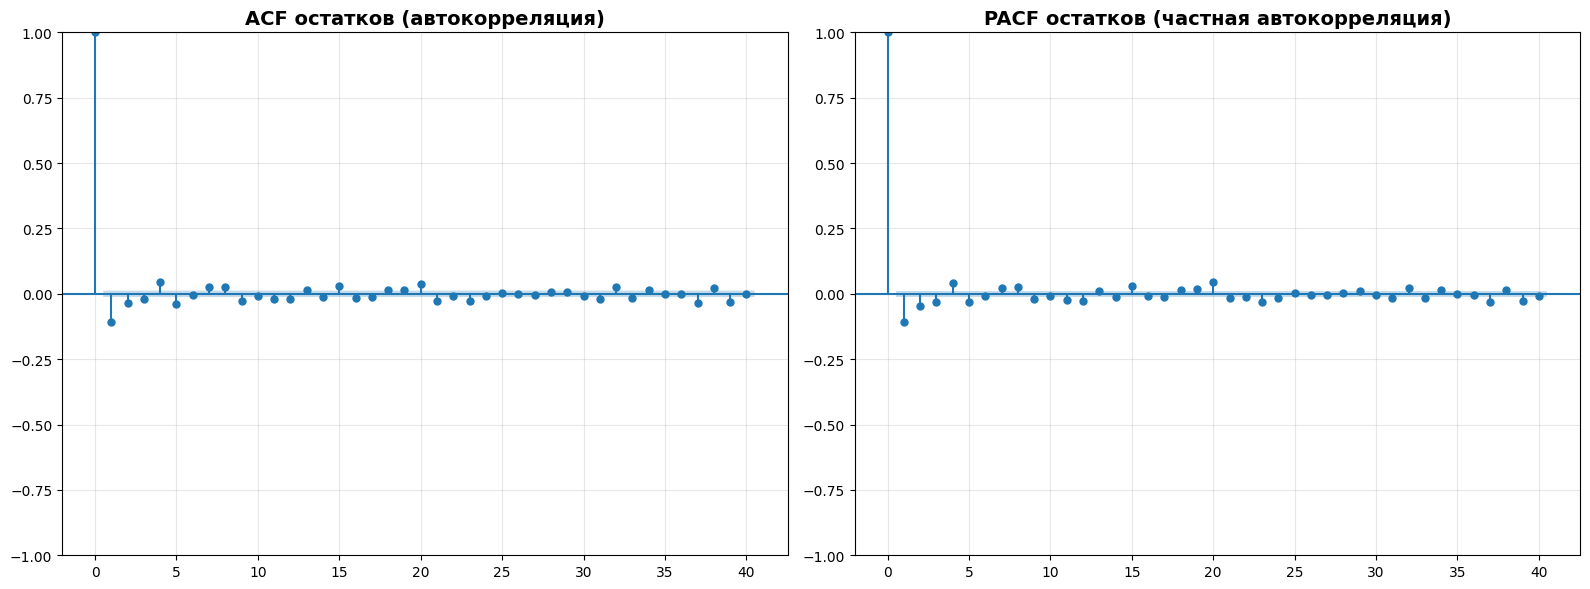


✅ Графики сохранены в 'autocorrelation_diagnostics.png'


In [40]:
# Визуализация ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF
plot_acf(residuals.values, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF остатков (автокорреляция)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(residuals.values, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF остатков (частная автокорреляция)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autocorrelation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'autocorrelation_diagnostics.png'")

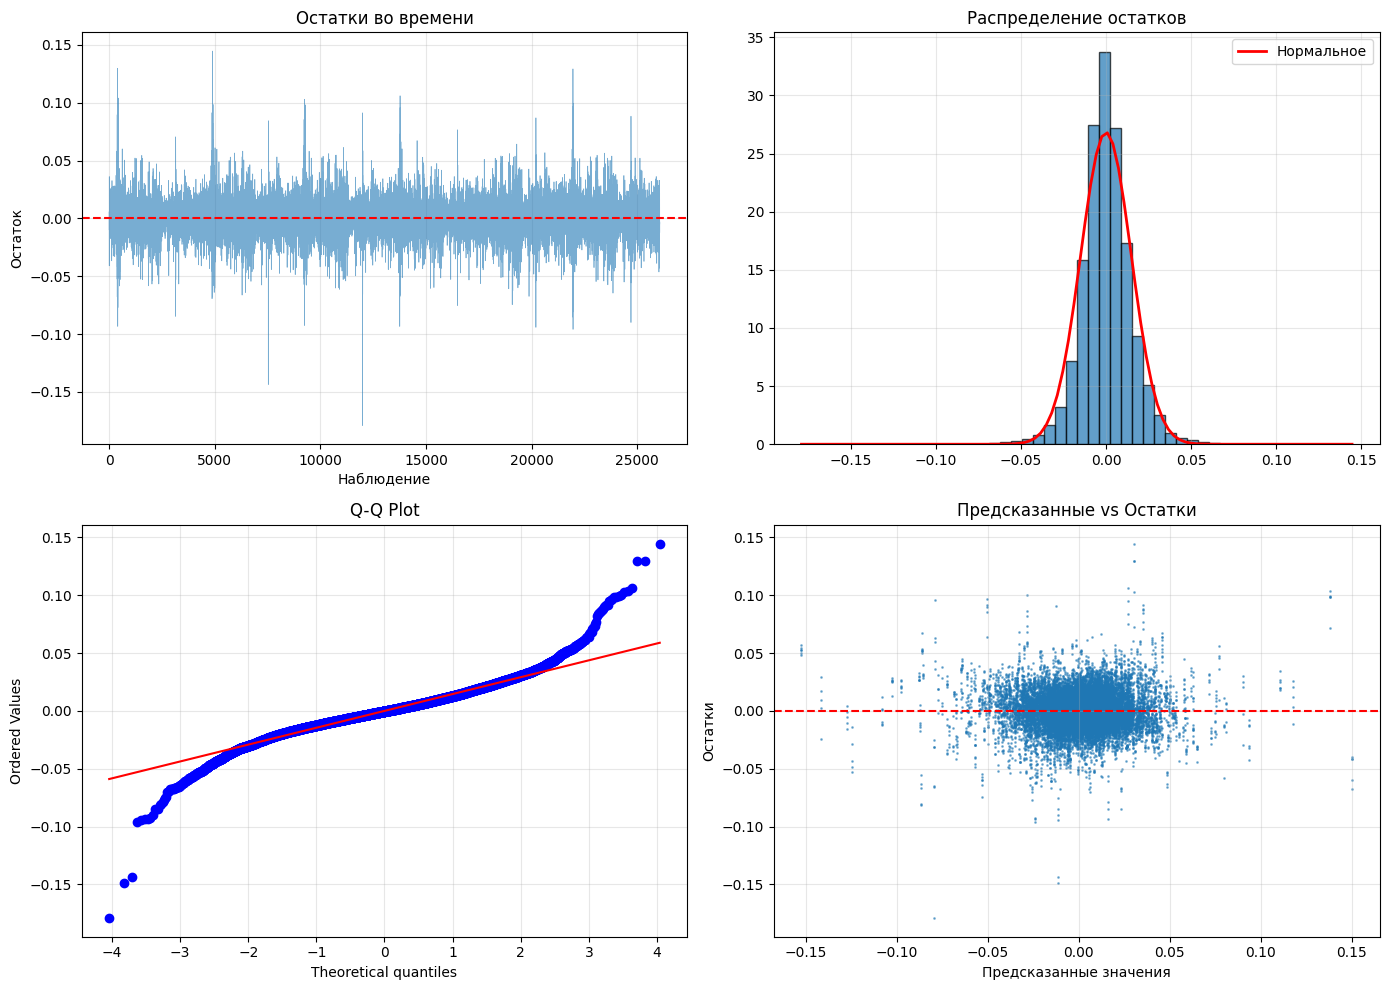


✅ Графики сохранены в 'residuals_diagnostics.png'


In [26]:
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals.values, alpha=0.6, linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].set_xlabel('Наблюдение')
axes[0, 0].set_ylabel('Остаток')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2, label='Нормальное')
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

fitted_values = best_model.fitted_values

axes[1, 1].scatter(fitted_values, residuals, alpha=0.5, s=1)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('Предсказанные vs Остатки')
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'residuals_diagnostics.png'")

In [27]:
# =============================================================================
# WALD-ТЕСТ НА ГИПОТЕЗУ β_gold == 1 (с учётом робастных ошибок)
# =============================================================================

print("\n" + "="*80)
print("ПРОВЕРКА ГИПОТЕЗЫ: β_gold = 1 (H1: β_gold > 1)")
print("="*80)

# Укажи точное имя переменной золота (проверь в results_fe.params.index)
gold_var = 'Gold_ret'   # ← если имя другое — поменяй здесь!

if gold_var not in results_fe.params.index:
    print(f"ОШИБКА: переменная '{gold_var}' не найдена в модели!")
    print("Доступные параметры:", list(results_fe.params.index))
else:
    # 1. Оценённый коэффициент и робастная стандартная ошибка
    beta = results_fe.params[gold_var]
    se   = results_fe.std_errors[gold_var]
    
    # 2. t-статистика для H0: β = 1
    t_stat = (beta - 1) / se
    
    # 3. Степени свободы (приближённо — df_resid или len(residuals)-k)
    df = results_fe.df_resid if hasattr(results_fe, 'df_resid') else len(results_fe.resids) - len(results_fe.params)
    
    # 4. p-value (односторонний для H1: β > 1)
    from scipy.stats import t
    p_one_sided = 1 - t.cdf(t_stat, df)   # если t_stat > 0
    
    # 5. Вывод
    print(f"β_gold (оценка)      = {beta:.4f}")
    print(f"Std. Error (robust)  = {se:.4f}")
    print(f"t-статистика (β=1)   = {t_stat:.4f}")
    print(f"Степени свободы      ≈ {df:.0f}")
    print(f"p-value (односторонний, β > 1) = {p_one_sided:.6f}")
    
    if p_one_sided < 0.01:
        print("→ Гипотеза β_gold > 1 принимается на уровне 1%")
    elif p_one_sided < 0.05:
        print("→ Гипотеза β_gold > 1 принимается на уровне 5%")
    elif p_one_sided < 0.10:
        print("→ Гипотеза β_gold > 1 принимается на уровне 10%")
    else:
        print("→ Нет оснований отвергнуть H0: β_gold ≤ 1")

    # 6. Альтернатива: t_test из statsmodels (часто работает стабильнее)
    print("\nАльтернативный t-тест через statsmodels:")
    try:
        ttest_res = results_fe.t_test(f"{gold_var} = 1")
        print(ttest_res)
    except Exception as e:
        print("t_test не сработал:", str(e))
        print("→ Используйте ручной расчёт выше — он надёжнее при кластеризованных ошибках.")


ПРОВЕРКА ГИПОТЕЗЫ: β_gold = 1 (H1: β_gold > 1)
β_gold (оценка)      = 1.5888
Std. Error (robust)  = 0.0558
t-статистика (β=1)   = 10.5465
Степени свободы      ≈ 26057
p-value (односторонний, β > 1) = 0.000000
→ Гипотеза β_gold > 1 принимается на уровне 1%

Альтернативный t-тест через statsmodels:
t_test не сработал: 'PanelEffectsResults' object has no attribute 't_test'
→ Используйте ручной расчёт выше — он надёжнее при кластеризованных ошибках.


## 8. Фиксированные эффекты по индексам

In [ ]:
print("="*80)
print("📊 ФИКСИРОВАННЫЕ ЭФФЕКТЫ ПО ИНДЕКСАМ")
print("="*80)

# Получаем фиксированные эффекты
fe_effects = results_fe.estimated_effects

# Проверяем структуру данных
print(f"Тип fe_effects: {type(fe_effects)}")
print(f"Форма fe_effects: {fe_effects.shape if hasattr(fe_effects, 'shape') else 'N/A'}")
print(f"Первые несколько значений:\n{fe_effects.head()}")

# Способ 1: Если estimated_effects это Series с мультииндексом
if isinstance(fe_effects, pd.Series):
    # Группируем по первому уровню индекса
    fe_by_index = fe_effects.groupby(level=0).mean()
    
    # Создаем DataFrame
    fe_df = pd.DataFrame({
        'Index': fe_by_index.index,
        'Fixed_Effect': fe_by_index.values.flatten()
    }).sort_values('Fixed_Effect', ascending=False)

# Способ 2: Если estimated_effects это DataFrame
elif isinstance(fe_effects, pd.DataFrame):
    fe_by_index = fe_effects.groupby(level=0).mean()
    fe_df = pd.DataFrame({
        'Index': fe_by_index.index,
        'Fixed_Effect': fe_by_index.iloc[:, 0].values
    }).sort_values('Fixed_Effect', ascending=False)

# Добавляем ранг
fe_df['Rank'] = range(1, len(fe_df) + 1)

print("\n📋 Топ-10 индексов с наибольшими фиксированными эффектами:")
print(fe_df.head(10).to_string(index=False))

print("\n📋 Индексы с наименьшими фиксированными эффектами:")
print(fe_df.tail(10).to_string(index=False))

print("\n📊 Статистика фиксированных эффектов:")
print(f"  Среднее: {fe_df['Fixed_Effect'].mean():.6f}")
print(f"  Медиана: {fe_df['Fixed_Effect'].median():.6f}")
print(f"  Стандартное отклонение: {fe_df['Fixed_Effect'].std():.6f}")
print(f"  Минимум: {fe_df['Fixed_Effect'].min():.6f}")
print(f"  Максимум: {fe_df['Fixed_Effect'].max():.6f}")

print("\n📊 Интерпретация:")
print("  + эффект → более высокая доходность (индекс outperforms)")
print("  - эффект → более низкая доходность (индекс underperforms)")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x > 0 else 'red' for x in fe_df['Fixed_Effect']]
bars = ax.barh(fe_df['Index'], fe_df['Fixed_Effect'], color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Фиксированный эффект')
ax.set_ylabel('Индекс')
ax.set_title('Фиксированные эффекты по индексам')
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, fe_df['Fixed_Effect'])):
    ax.text(val, i, f' {val:.4f}', va='center', ha='left' if val > 0 else 'right')

plt.tight_layout()
plt.savefig('fixed_effects.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ График сохранен в 'fixed_effects.png'")

## 9. Итоговые выводы

In [ ]:
print("="*80)
print("📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*80)

print("\n📌 1. СТАЦИОНАРНОСТЬ:")
print(f"   ✅ Все {len(stationarity_summary)} переменных стационарны")

print("\n📌 2. МУЛЬТИКОЛЛИНЕАРНОСТЬ:")
if 'vif_data' in locals():
    high_vif_count = len(vif_data[vif_data['VIF'] >= 10])
    if high_vif_count == 0:
        print("   ✅ Нет сильной мультиколлинеарности")
    else:
        print(f"   ⚠️ {high_vif_count} переменных с VIF >= 10")

print("\n📌 3. ИНФОРМАЦИОННЫЕ КРИТЕРИИ:")

if hasattr(results_pooled, 'aic'):
    print(f"   Pooled OLS AIC:     {results_pooled.aic:.2f}")
    print(f"   Pooled OLS BIC:     {results_pooled.bic:.2f}")
else:
    print("   Pooled OLS: информационные критерии недоступны")

if hasattr(results_fe, 'info_criteria'):
    if 'aic' in results_fe.info_criteria:
        print(f"   Fixed Effects AIC:  {results_fe.info_criteria['aic']:.2f}")
    if 'bic' in results_fe.info_criteria:
        print(f"   Fixed Effects BIC:  {results_fe.info_criteria['bic']:.2f}")
else:
    print("   Fixed Effects: информационные критерии недоступны")

if hasattr(results_re, 'info_criteria'):
    if 'aic' in results_re.info_criteria:
        print(f"   Random Effects AIC: {results_re.info_criteria['aic']:.2f}")
    if 'bic' in results_re.info_criteria:
        print(f"   Random Effects BIC: {results_re.info_criteria['bic']:.2f}")
else:
    print("   Random Effects: информационные критерии недоступны")

print("\n📌 4. ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ (FE с робастными ошибками):")
for var in available_macro:
    if var in results_fe.params.index:
        coef = results_fe.params[var]
        pval = results_fe.pvalues[var]
        stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        sig = "значим" if pval < 0.05 else "незначим"
        print(f"   {var:15}: {coef:8.4f} {stars:3} (p={pval:.4f}, {sig})")

print("\n📌 5. КАЧЕСТВО МОДЕЛИ:")
if hasattr(results_fe, 'rsquared_within'):
    print(f"   R² (within):  {results_fe.rsquared_within:.4f}")
if hasattr(results_fe, 'rsquared_between'):
    print(f"   R² (between): {results_fe.rsquared_between:.4f}")
if hasattr(results_fe, 'rsquared_overall'):
    print(f"   R² (overall): {results_fe.rsquared_overall:.4f}")

print("\n📌 6. ДИАГНОСТИКА:")
if 'jb_pvalue' in locals():
    print(f"   Нормальность:  {'❌ Отвергается' if jb_pvalue < 0.05 else '✅ Принимается'} (JB p={jb_pvalue:.4f})")
if 'bp_pvalue' in locals():
    print(f"   Гетероскед:    {'⚠️ Обнаружена' if bp_pvalue < 0.05 else '✅ Не обнаружена'} (BP p={bp_pvalue:.4f})")
print(f"   (Робастные ошибки применены)")

print("\n📌 7. ТЕСТ ХАУСМАНА (FE vs RE):")
if 'hausman_choice' in locals():
    print(f"   Выбор модели: {hausman_choice}")
else:
    print("   Тест Хаусмана не проводился")

In [ ]:
# Сохранение результатов
print("\n" + "="*80)
print("💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*80)

coef_re_list = []
std_error_re_list = []
p_value_re_list = []

for var in available_macro:
    if var in results_re.params.index:
        coef_re_list.append(results_re.params[var])
        std_error_re_list.append(results_re.std_errors[var])
        p_value_re_list.append(results_re.pvalues[var])
    else:
        coef_re_list.append(np.nan)
        std_error_re_list.append(np.nan)
        p_value_re_list.append(np.nan)

results_summary = pd.DataFrame({
    'Variable': available_macro,
    'Coefficient_FE': [results_fe.params[var] for var in available_macro],
    'Std_Error_FE': [results_fe.std_errors[var] for var in available_macro],
    'P_value_FE': [results_fe.pvalues[var] for var in available_macro],
    'Coefficient_RE': coef_re_list,
    'Std_Error_RE': std_error_re_list,
    'P_value_RE': p_value_re_list,
})

results_summary.to_csv('results/panel_regression_results.csv', index=False)
print("✅ Результаты регрессий: results/panel_regression_results.csv")

fe_df.to_csv('results/fixed_effects.csv', index=False)
print("✅ Фиксированные эффекты: results/fixed_effects.csv")

stationarity_summary.to_csv('results/stationarity_tests.csv', index=False)
print("✅ Тесты на стационарность: results/stationarity_tests.csv")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("="*80)